# fourier-cosine-option-pricing — demo notebook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ee2625/fourier-cosine-option-pricing/blob/main/notebooks/demo.ipynb)

This notebook demonstrates the **novel work and use cases** of the package.
The paper-replication suite (F&O 2008 Tables 1–10 reproduced verbatim) has been
moved to a sibling paper-replication repo so this notebook can stay focused.
<!-- TODO: replace with the link once the pyfeng-for-papers PR lands -->
Link: *paper-replication repo — coming soon*.

What stays here:

- **§8 Dimensional (Buckingham π) invariance** — the project's original methodological work. BSM and Heston prices collapse onto low-dimensional surfaces under the natural spatial/temporal rescalings, verified across BSM, Heston, VG, and CGMY.
- **§9 Bermudan options → American limit** — F&O 2009 Bermudan put with M exercise dates, converging to its European limit at M = 1 and to its American limit as M → ∞. Use case: pricing American options through a Bermudan ladder.
- **§10 Post-presentation extensions** — strike-independent reusable COS setup, Junike–Pankrashkin (2022) truncation ranges, and Black-Scholes control variate.
- **§11 Final validation checklist** — the project's quality-control summary.

Section numbers 8–11 are preserved from our internal validation notebook so cross-references with the paper-replication repo line up.

## What the COS method is doing

The COS method prices options by approximating the risk-neutral log-price density with a finite cosine series on a truncated interval $[a,b]$, reading the cosine coefficients from the model's characteristic function, and dot-producting those coefficients against analytic payoff integrals.

The starting point is the risk-neutral expectation

$$
V_0 = e^{-rT}E[(S_T-K)^+].
$$

For many models, especially Heston, VG, and CGMY, we know the **characteristic function**

$$
\varphi(u)=E[e^{iuX_T}],
$$

more easily than we know the density. The characteristic function is the Fourier transform of the probability distribution: it describes the law of the future log-price $X_T$ in frequency space, and it can be inverted or sampled to recover density information.

Model context:

- **Heston** is a stochastic-volatility model where variance follows a mean-reverting square-root process and is correlated with stock returns, which creates volatility smiles and skew.
- **Variance Gamma (VG)** is a pure-jump Lévy model that runs Brownian motion on a random Gamma clock, giving skewness and fat tails without ordinary continuous diffusion.
- **CGMY** is a four-parameter pure-jump Lévy model where $C$ controls jump activity, $G$ and $M$ control left/right tail decay, and $Y$ controls the fine structure of small jumps.

COS uses the characteristic function to recover the cosine coefficients of the density:

$$
u_k = \frac{k\pi}{b-a}, \qquad
A_k \approx \frac{2}{b-a}\operatorname{Re}\left[\varphi(u_k)e^{-iu_k a}\right].
$$

Then the option price is

$$
V(x,t)=K e^{-r\tau}\operatorname{Re}\left[\sum_{k=0}^{N-1}{}' \varphi\left(\frac{k\pi}{b-a}\right)e^{ik\pi(x-a)/(b-a)}V_k\right],
$$

where the prime means the $k=0$ term is halved. The payoff coefficients are analytic:

$$
\chi_k(c,d)=\int_c^d e^x\cos\left(k\pi\frac{x-a}{b-a}\right)dx,\qquad
\psi_k(c,d)=\int_c^d \cos\left(k\pi\frac{x-a}{b-a}\right)dx.
$$

For a vanilla call, $V_k = \frac{2}{b-a}[\chi_k(0,b)-\psi_k(0,b)]$.

**Important knobs.** $N$ is the number of cosine terms; $[a,b]$ is the log-price truncation interval; $L$ is the safety multiplier used to build $[a,b]$ from cumulants. If $[a,b]$ is too narrow, we cut off tail probability. If it is too wide, we waste resolution.

**How to read `< 2e-14`.** Standard double precision has machine epsilon

$$
\epsilon_{mach}=2.220446049250313\times 10^{-16}.
$$

Most benchmark prices are on the scale of $S_0\approx 100$, so the price-scale floating-point floor is

$$
100\epsilon_{mach}=2.220446049250313\times 10^{-14}\approx 2\times 10^{-14}.
$$

When a residual is displayed as `< 2e-14`, it means the difference is below this display floor; it is not a paper result and it is not a skipped calculation.

**Why COS is fast.** COS works on a finite interval, samples the characteristic function at real frequencies only, and integrates the payoff analytically. For smooth densities, cosine coefficients decay exponentially, so increasing $N$ buys accuracy very quickly.

| Method | What it discretizes | Main tradeoff |
|---|---|---|
| Carr-Madan | FFT of a damped call-price transform in log-strike | Good for many strikes, but needs damping $\alpha$ and converges algebraically here |
| Lewis | One Fourier integral on the fixed contour $u-i/2$ | Accurate and no damping parameter, but usually per-strike |
| COS | Density cosine expansion on $[a,b]$ plus analytic payoff coefficients | Very fast when $[a,b]$ is chosen well |
| FrFT | Carr-Madan integrand with a fractional FFT grid | Better strike-grid control than FFT, same damping tradeoff |

**Damping.** Carr-Madan needs damping because the raw call payoff is not Fourier-integrable in log-strike. It prices a transformed call $c_T(k)=e^{\alpha k}C(e^k)$, inverts the transform, then removes the damping. If $\alpha$ is too small the integral decays slowly; if too large the complex-shifted characteristic function can become unstable. Lewis effectively uses the symmetric shift $u-i/2$, removing the tuning choice. COS does not need damping because the payoff is integrated analytically over the finite interval $[a,b]$.

**Implementation story.** The algorithm is language-independent. MATLAB and NumPy are both natural for vectorized numerical work, but our Heston implementation also uses Numba: the complex arithmetic loop over $k=0,\ldots,N-1$ is JIT-compiled to machine code, avoiding Python overhead and many temporary arrays. The repo also includes a [PyFENG](https://github.com/PyFE/PyFENG)-compatible implementation under `pyfeng/`, following Prof. Choi's `CosABC`, `BsmCos`, and `HestonCos` class structure so our COS pricer can be compared directly with PyFENG's existing Fourier pricers.

**Le Floc'h / robust COS context.** Le Floc'h (2020), *More Robust Pricing of European Options Based on Fourier Cosine Series Expansions*, focuses on making the COS truncation range more robust and less hand-tuned. This matters because the original Fang-Oosterlee range is cumulant-based and partly controlled by a heuristic $L$. For volatility smiles, we want strike-independent ranges and reusable coefficients; Le Floc'h is a practical reference, while Junike-Pankrashkin (2022) gives a sharper error-controlled truncation-range framework.


In [ ]:
# Colab setup -- clones the repo so the project's custom pyfeng/* extensions
# (BsmCos, HestonCos, BermudanBsmCos, BsmFrft, ...) are available, then
# installs the only extra PyPI dependency. After this cell, every other
# cell runs exactly as it does locally.
!git clone --quiet https://github.com/ee2625/fourier-cosine-option-pricing.git
%cd fourier-cosine-option-pricing
!pip install --quiet pyfeng

In [1]:
import os, sys, time
ROOT = os.path.abspath(os.path.join(os.getcwd(),
    ".." if os.path.basename(os.getcwd()) == "notebooks" else "."))
sys.path[:] = [p for p in sys.path if os.path.abspath(p) not in (ROOT, "")]
import pyfeng as pf, importlib
pyfeng_local = os.path.join(ROOT, "pyfeng")
if pyfeng_local not in pf.__path__:
    pf.__path__.append(pyfeng_local)
importlib.invalidate_caches()
sys.path.insert(0, os.path.join(ROOT, "src"))
from cos_pricing import bsm_price

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 -- registers 3d projection
from scipy.stats import norm

from pyfeng.sv_cos        import BsmCos
from pyfeng.sv_heston_cos import HestonCos
from pyfeng.lv_cos        import VarGammaCos, CgmyCos
from pyfeng.bermudan_cos  import BermudanBsmCos
from pyfeng.frft          import BsmFrft

pd.set_option("display.float_format", lambda x: f"{x:.6g}")
plt.rcParams["figure.dpi"] = 100

FLOAT_EPS = np.finfo(float).eps      # 2.22e-16 for IEEE double precision
PRICE_SCALE = 100.0                  # prices in these benchmarks are O(S0), with S0 around 100
ERR_FLOOR = PRICE_SCALE * FLOAT_EPS  # about 2.22e-14; display floor, not a paper result

def _is_error_col(col):
    label = " ".join(map(str, col)) if isinstance(col, tuple) else str(col)
    return "err" in label.lower()

def display_error_table(df, floor=ERR_FLOOR):
    """Show errors below price-scale double precision as '< floor' instead of literal 0.0."""
    shown = df.copy()
    for col in shown.columns:
        if _is_error_col(col):
            shown[col] = shown[col].map(
                lambda x: f"< {floor:.0e}" if pd.notna(x) and abs(float(x)) < floor else x
            )
    display(shown)

def display_small_residuals(df, cols=None, floor=ERR_FLOOR):
    """Show tiny symmetry residuals/spreads as '< floor' instead of literal 0.0."""
    shown = df.copy()
    if cols is None:
        cols = [
            col for col in shown.columns
            if any(tok in str(col).lower() for tok in ("err", "residual", "spread"))
        ]
    for col in cols:
        shown[col] = shown[col].map(
            lambda x: f"< {floor:.0e}" if pd.notna(x) and abs(float(x)) < floor else x
        )
    display(shown)

def plot_values(vals, col, floor=ERR_FLOOR):
    arr = np.asarray(vals, dtype=float)
    return np.maximum(arr, floor) if _is_error_col(col) else arr

def bench(call_fn, ref, reps=200):
    p   = call_fn()
    err = float(np.max(np.abs(p - ref)))
    t0  = time.perf_counter()
    for _ in range(reps): call_fn()
    return err, (time.perf_counter() - t0) / reps * 1e3

print("imports OK")

imports OK


## Dimensional analysis story

The short version from the class slides is:

1. Equations must be dimensionally homogeneous.
2. Inputs to $\log(x)$, $e^x$, $\sin(x)$, and $\cos(x)$ must be dimensionless.
3. Buckingham's $\pi$ theorem reduces raw dimensional variables to dimensionless groups.

For Black-Scholes, the variables are $C,S_0,K,r,\sigma,T$ with price and time as base dimensions. The dimensionless representation is

$$
\frac{C}{S_0}=f\left(\frac{K}{S_0},\sigma\sqrt{T},rT\right).
$$

This immediately implies scale invariance:

$$
S_0\to \lambda S_0,\quad K\to \lambda K \quad \Rightarrow \quad C\to \lambda C.
$$

This also explains why Fourier option pricing naturally uses log-moneyness: $\log(S_0/K)$ is legal because $S_0/K$ is dimensionless.

**What the tables show.** The spatial scale-invariance tables test $C(\lambda S_0,\lambda K)=\lambda C(S_0,K)$ across BSM, Heston, VG, and CGMY. The errors are around $10^{-16}$ to $10^{-14}$, which is floating-point noise. So these are not just numerical benchmarks; they are structural correctness checks.

**What the BSM image shows.** The BSM collapse plot shows the surface $C/S_0=f(K/S_0,\sigma\sqrt{T})$. Different raw triples $(S_0,T,\sigma)$ land on the same surface when their dimensionless groups match. That is the visual version of Buckingham $\pi$.

**What the Heston image shows.** Heston has more parameters, but the same idea holds. After fixing the dimensionless Heston groups such as $\rho$, $\kappa T$, $\bar vT$, $\eta T$, and $(r-q)T$, the plotted slice becomes $C/S_0=f(K/S_0,\sqrt{v_0T})$. Different raw Heston parameter sets collapse onto the same surface.

**Why this matters.** Dimensional analysis acts as a test harness: if the pricer violates a symmetry predicted by Buckingham $\pi$, then something is wrong in the implementation, even if no closed-form benchmark is available.


# 8. Dimensional (Buckingham π) invariance

The project's original methodological work beyond F&O 2008. Coordinate changes that leave the SDE invariant should leave the dimensionless price invariant -- this catches unit, truncation, and discounting slips that closed-form checks can miss.

This notebook displays spatial scale invariance for all four models, then shows the temporal and joint spatial-temporal rotation in detail for Heston. The VG and CGMY temporal rotations are validated in the automated test suite and summarized in the README.

| Model | π-groups | Checks shown here |
|---|---|---|
| BSM    | 3 | spatial scale + dimensionless surface collapse |
| Heston | 8 | spatial scale + temporal rotation + joint spatial-temporal + dimensionless surface collapse |
| VG     | 5 | spatial scale |
| CGMY   | 6 | spatial scale |


## 8.1 &nbsp; BSM scale invariance

Multiply $S$ and $K$ by the same $\lambda$. Since $K/S$ is the only dimensionless moneyness group, $C/S$ should not change.

The table reports the worst normalized residual, $|C(\lambda S,\lambda K)/(\lambda S)-C(S,K)/S|$, across strikes and maturities. Values below the display floor are shown as `< 2e-14`, meaning floating-point-level agreement rather than missing data.


In [9]:
LAMBDAS = [0.1, 0.5, 2.0, 10.0, 100.0]
SPOT, STRIKES_PI, TEXPS = 100.0, np.array([70., 85., 100., 115., 130.]), [0.1, 1.0, 5.0]
bsm_pi = BsmCos(sigma=0.25, intr=0.05, divr=0.02)

rows = []
for lam in LAMBDAS:
    for cp in (+1, -1):
        worst = 0.0
        for texp in TEXPS:
            base   = bsm_pi.price(STRIKES_PI,       SPOT,       texp, cp=cp)
            scaled = bsm_pi.price(STRIKES_PI * lam, SPOT * lam, texp, cp=cp)
            worst  = max(worst, float(np.max(np.abs(scaled / SPOT / lam - base / SPOT))))
        rows.append((lam, "call" if cp == +1 else "put", worst))

df_bsm_scale = pd.DataFrame(rows, columns=["lambda", "cp", "worst normalized residual"])
display_small_residuals(df_bsm_scale)


,lambda,cp,worst normalized residual
0,0.1,call,< 2e-14
1,0.1,put,< 2e-14
2,0.5,call,< 2e-14
3,0.5,put,< 2e-14
4,2,call,< 2e-14
5,2,put,< 2e-14
6,10,call,< 2e-14
7,10,put,< 2e-14
8,100,call,< 2e-14
9,100,put,< 2e-14


## 8.2 &nbsp; BSM dimensionless collapse (`docs/fig_bsm_collapse.png`)

BSM with $r = q = 0$ reduces to two π-groups: $K/S_0$ and $\sigma\sqrt{T}$. The whole BSM call surface lives on $C/S_0 = f(K/S_0, \sigma\sqrt{T})$. Three raw triples with 16× range in $(S_0, T, \sigma)$ all land on the same surface -- the visual π-theorem.

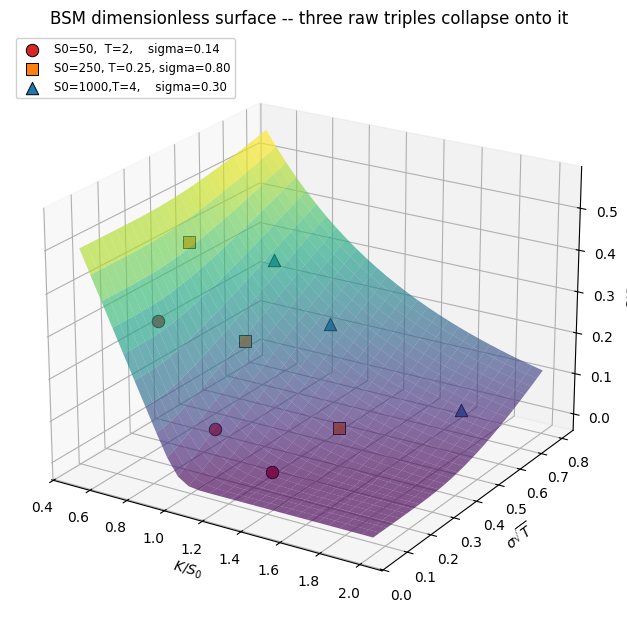

,K/S0,triple 1,triple 2,triple 3,spread
0,0.7,0.333712,0.333712,0.333712,< 2e-14
1,1,0.158519,0.158519,0.158519,< 2e-14
2,1.3,0.0693964,0.0693964,0.0693964,< 2e-14
3,1.6,0.029475,0.029475,0.029475,< 2e-14


In [10]:
L_BSM, N_K_s, N_V_s = 20.0, 28, 28
k_over_s   = np.linspace(0.5, 2.0, N_K_s)
sig_sqT    = np.linspace(0.05, 0.8, N_V_s)
KK_s, VV_s = np.meshgrid(k_over_s, sig_sqT, indexing="ij")

def bsm_surface(S0, T, KK, VV):
    Z = np.empty_like(KK)
    for j in range(VV.shape[1]):
        m = BsmCos(sigma=float(VV[0, j] / np.sqrt(T))); m.L = L_BSM
        Z[:, j] = m.price(KK[:, j] * S0, S0, T, cp=+1) / S0
    return Z

Z_bsm = bsm_surface(100.0, 1.0, KK_s, VV_s)

triples = [
    ("S0=50,  T=2,    sigma=0.14",   50.0, 2.00, 0.14, np.array([0.7, 1.0, 1.3])),
    ("S0=250, T=0.25, sigma=0.80",  250.0, 0.25, 0.80, np.array([0.6, 0.9, 1.4])),
    ("S0=1000,T=4,    sigma=0.30", 1000.0, 4.00, 0.30, np.array([0.8, 1.1, 1.8])),
]

fig = plt.figure(figsize=(9, 6.5))
ax  = fig.add_subplot(111, projection="3d")
ax.plot_surface(KK_s, VV_s, Z_bsm, cmap="viridis", alpha=0.65, linewidth=0, antialiased=True)
for (lbl, S0, T, sig, mn), col, mk in zip(triples,
        ["#d62728", "#ff7f0e", "#1f77b4"], ["o", "s", "^"]):
    m  = BsmCos(sigma=sig); m.L = L_BSM
    px = m.price(mn * S0, S0, T, cp=+1) / S0
    ax.scatter(mn, np.full_like(mn, sig * np.sqrt(T)), px, s=80, color=col,
               marker=mk, edgecolor="black", linewidth=0.7, label=lbl, depthshade=False)
ax.set(xlabel=r"$K/S_0$", ylabel=r"$\sigma\sqrt{T}$", zlabel=r"$C/S_0$")
ax.set_title("BSM dimensionless surface -- three raw triples collapse onto it")
ax.view_init(elev=22, azim=-58); ax.legend(loc="upper left", fontsize=8.5, framealpha=0.92)
fig.tight_layout(); plt.show()

# Numeric collapse at sigma*sqrt(T) = 0.4
common = [(50.0, 2.00, 0.4 / np.sqrt(2.00)),
          (250.0, 0.25, 0.4 / np.sqrt(0.25)),
          (1000.0, 4.00, 0.4 / np.sqrt(4.00))]
rows = []
for moneyness in [0.7, 1.0, 1.3, 1.6]:
    row = [moneyness]
    for S0, T, sig in common:
        m = BsmCos(sigma=sig); m.L = L_BSM
        row.append(float(m.price(moneyness * S0, S0, T, cp=+1)) / S0)
    row.append(max(row[1:]) - min(row[1:]))
    rows.append(row)
df_bsm_collapse = pd.DataFrame(rows, columns=["K/S0", "triple 1", "triple 2", "triple 3", "spread"])
display_small_residuals(df_bsm_collapse, cols=["spread"])

## 8.3 &nbsp; Spatial scale invariance -- all four pricers

This repeats the same scale test across BSM, Heston, VG, and CGMY. The residual column is the worst normalized difference after scaling both spot and strike by $\lambda$. Values shown as `< 2e-14` are floating-point-level agreement.


In [11]:
def _bsm   (S, K, T, cp): return BsmCos(sigma=0.25).price(K, S, T, cp=cp)
def _heston(S, K, T, cp): return HestonCos(sigma=0.04, vov=0.5, mr=1.5, theta=0.04, rho=-0.5).price(K, S, T, cp=cp)
def _vg    (S, K, T, cp):
    m = VarGammaCos(sigma=0.12, theta=-0.14, vov=0.2); m.n_cos = 256
    return m.price(K, S, T, cp=cp)
def _cgmy  (S, K, T, cp):
    m = CgmyCos(C=1.0, G=5.0, M=5.0, Y=0.5); m.n_cos = 256
    return m.price(K, S, T, cp=cp)

PRICERS = [("BsmCos", _bsm), ("HestonCos", _heston), ("VarGammaCos", _vg), ("CgmyCos", _cgmy)]
SPOT_PI2, STRIKES_PI2, TEXPS_PI2, LAMBDAS_PI2 = 100.0, np.array([85., 100., 115.]), [0.5, 1.0, 2.0], LAMBDAS

rows = []
for name, pricer in PRICERS:
    for lam in LAMBDAS_PI2:
        worst = 0.0
        for cp in (+1, -1):
            for texp in TEXPS_PI2:
                base  = np.array([pricer(SPOT_PI2,       K,       texp, cp) for K in STRIKES_PI2])
                other = np.array([pricer(SPOT_PI2 * lam, K * lam, texp, cp) for K in STRIKES_PI2])
                worst = max(worst, float(np.max(np.abs(other / (SPOT_PI2 * lam) - base / SPOT_PI2))))
        rows.append((name, lam, worst))

df_all_scale = pd.DataFrame(rows, columns=["model", "lambda", "worst normalized residual"])
display_small_residuals(df_all_scale)


,model,lambda,worst normalized residual
0,BsmCos,0.1,< 2e-14
1,BsmCos,0.5,< 2e-14
2,BsmCos,2,< 2e-14
3,BsmCos,10,< 2e-14
4,BsmCos,100,< 2e-14
5,HestonCos,0.1,< 2e-14
6,HestonCos,0.5,< 2e-14
7,HestonCos,2,< 2e-14
8,HestonCos,10,< 2e-14
9,HestonCos,100,< 2e-14


## 8.4 &nbsp; Heston temporal $\pi$-invariance

Substituting $t = \mu\tau'$ and rescaling Brownians by $\sqrt{\mu}$ leaves Heston dynamics invariant under $(T, r, q, \kappa, \eta, v_0, \bar u) \to (\mu T, r/\mu, q/\mu, \kappa/\mu, \eta/\mu, v_0/\mu, \bar u/\mu)$. We pin both pricers to the same absolute log-moneyness half-width so the COS grids are bit-identical.

The residual is the worst normalized price difference across the strike grid:

$$
\max_K\frac{|C_{resc}(K)-C_{base}(K)|}{S_0}.
$$

Values below the display floor are shown as `< 2e-14`; those are floating-point-level residuals, not skipped or missing rows.


In [12]:
MUS, STRIKES_H, TAU_BASE = LAMBDAS, np.array([70., 85., 100., 115., 130.]), 1.0
N_COS_H, HALF_WIDTH, S0_H = 256, 12.0, 100.0
BASE = dict(sigma=0.04, mr=1.5, vov=0.4, theta=0.04, rho=-0.7, intr=0.03, divr=0.01)

def rescale(p, mu):
    out = dict(p)
    for k in ("sigma", "mr", "vov", "theta", "intr", "divr"): out[k] = p[k] / mu
    return out
sigma_h = lambda p: float(np.sqrt(p["theta"] + p["sigma"] * p["vov"]))

def price_pinned(m, p, S0, K, tau, cp):
    m.n_cos, m.L = N_COS_H, HALF_WIDTH / sigma_h(p)
    return m.price(K, S0, tau, cp=cp)

rows = []
for mu in MUS:
    for cp in (+1, -1):
        bp, rp = BASE, rescale(BASE, mu)
        bm, rm = HestonCos(**bp), HestonCos(**rp)
        p_base = price_pinned(bm, bp, S0_H, STRIKES_H, TAU_BASE,      cp)
        p_resc = price_pinned(rm, rp, S0_H, STRIKES_H, mu * TAU_BASE, cp)
        worst  = float(np.max(np.abs(p_resc - p_base) / S0_H))
        rows.append((mu, "call" if cp == +1 else "put", worst))

resid_col_heston = "worst normalized residual"
df_heston_temporal = pd.DataFrame(rows, columns=["mu", "cp", resid_col_heston])
shown_heston_temporal = df_heston_temporal.copy()
shown_heston_temporal[resid_col_heston] = shown_heston_temporal[resid_col_heston].map(
    lambda x: f"< {ERR_FLOOR:.0e}" if abs(float(x)) < ERR_FLOOR else x
)
display(shown_heston_temporal)


,mu,cp,worst normalized residual
0,0.1,call,5.63099e-12
1,0.1,put,< 2e-14
2,0.5,call,< 2e-14
3,0.5,put,< 2e-14
4,2,call,< 2e-14
5,2,put,< 2e-14
6,10,call,7.46908e-12
7,10,put,< 2e-14
8,100,call,5.43052e-12
9,100,put,< 2e-14


## 8.5 &nbsp; Heston dimensionless collapse (`docs/fig_heston_collapse.png`)

Heston has 8 π-groups -- after fixing the five rate-dimensioned ones ($\rho$, $\kappa T$, $\bar v T$, $\eta T$, $(r-q)T$), the price lives on $C/S_0 = f(K/S_0, \sqrt{v_0 T})$. Three sextets with very different raw $(S_0, T, v_0, \kappa, \bar u, \eta)$ collapse onto the same surface.

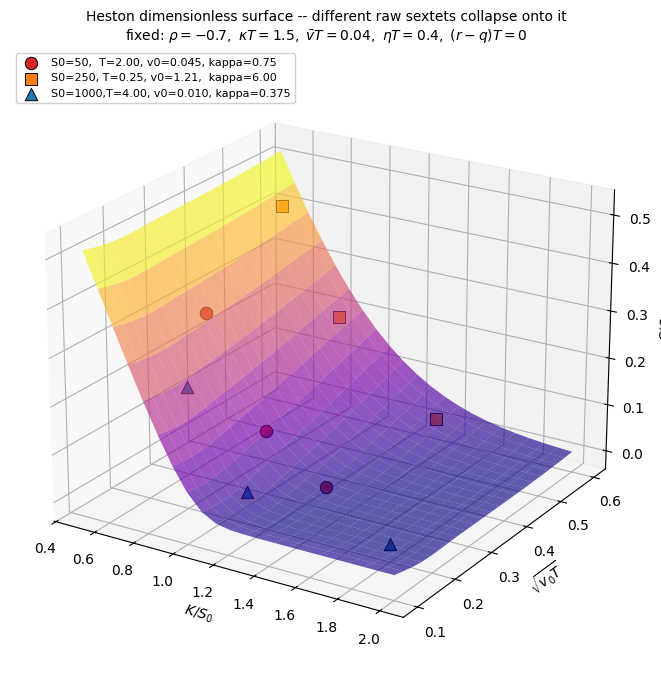

,K/S0,triple 1,triple 2,triple 3,spread
0,0.7,0.324371,0.324371,0.324371,< 2e-14
1,1,0.120087,0.120087,0.120087,< 2e-14
2,1.3,0.0245684,0.0245684,0.0245684,< 2e-14
3,1.6,0.0027273,0.0027273,0.0027273,< 2e-14


In [13]:
PI_RHO, PI_RT, PI_KAPPA_T, PI_UBAR_T, PI_ETA_T = -0.70, 0.0, 1.50, 0.04, 0.40
N_Kh, N_Vh, HALF_WIDTH_H, N_COS_H_PLOT = 22, 22, 10.0, 256
k_over_sh = np.linspace(0.5, 2.0, N_Kh)
sqrt_v0T  = np.linspace(0.10, 0.60, N_Vh)
KKh, VVh  = np.meshgrid(k_over_sh, sqrt_v0T, indexing="ij")

def _make(T, sigT):
    return HestonCos(sigma=sigT**2 / T, mr=PI_KAPPA_T / T, vov=PI_ETA_T / T,
                     theta=PI_UBAR_T / T, rho=PI_RHO, intr=PI_RT / T, divr=0.0)
_L_for = lambda m: HALF_WIDTH_H / float(np.sqrt(m.theta + m.sigma * m.vov))

def heston_surface(S0, T, KK, VV):
    Z = np.empty_like(KK)
    for j in range(VV.shape[1]):
        m = _make(T, float(VV[0, j])); m.n_cos, m.L = N_COS_H_PLOT, _L_for(m)
        Z[:, j] = m.price(KK[:, j] * S0, S0, T, cp=+1) / S0
    return Z

Z_h = heston_surface(100.0, 1.0, KKh, VVh)

spread_specs = [
    (   50.0, 2.00, 0.30, np.array([0.7, 1.0, 1.3]), "S0=50,  T=2.00, v0=0.045, kappa=0.75"),
    (  250.0, 0.25, 0.55, np.array([0.6, 0.9, 1.4]), "S0=250, T=0.25, v0=1.21,  kappa=6.00"),
    ( 1000.0, 4.00, 0.20, np.array([0.8, 1.1, 1.8]), "S0=1000,T=4.00, v0=0.010, kappa=0.375"),
]

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection="3d")
ax.plot_surface(KKh, VVh, Z_h, cmap="plasma", alpha=0.65, linewidth=0, antialiased=True)
for (S0, T, sigT, mn, lbl), col, mk in zip(spread_specs,
        ["#d62728", "#ff7f0e", "#1f77b4"], ["o", "s", "^"]):
    m  = _make(T, sigT); m.n_cos, m.L = N_COS_H_PLOT, _L_for(m)
    px = m.price(mn * S0, S0, T, cp=+1) / S0
    ax.scatter(mn, np.full_like(mn, sigT), px, s=80, color=col,
               marker=mk, edgecolor="black", linewidth=0.7, label=lbl, depthshade=False)
ax.set(xlabel=r"$K/S_0$", ylabel=r"$\sqrt{v_0 T}$", zlabel=r"$C/S_0$")
ax.set_title("Heston dimensionless surface -- different raw sextets collapse onto it\n"
             r"fixed: $\rho=-0.7,\ \kappa T=1.5,\ \bar v T=0.04,\ \eta T=0.4,\ (r-q)T=0$",
             fontsize=10)
ax.legend(loc="upper left", fontsize=8, framealpha=0.92); ax.view_init(elev=22, azim=-58)
fig.tight_layout(); plt.show()

common = [(50.0, 2.00, 0.40), (250.0, 0.25, 0.40), (1000.0, 4.00, 0.40)]
rows = []
for moneyness in [0.7, 1.0, 1.3, 1.6]:
    row = [moneyness]
    for S0, T, sigT in common:
        m = _make(T, sigT); m.n_cos, m.L = N_COS_H_PLOT, _L_for(m)
        row.append(float(m.price(moneyness * S0, S0, T, cp=+1)) / S0)
    row.append(max(row[1:]) - min(row[1:]))
    rows.append(row)
df_heston_collapse = pd.DataFrame(rows, columns=["K/S0", "triple 1", "triple 2", "triple 3", "spread"])
display_small_residuals(df_heston_collapse, cols=["spread"])

## 8.6 &nbsp; Joint spatial × temporal

Spatial scale $\alpha$ on $(S_0, K)$ combined with temporal rotation $\mu$ -- two of the eight $\pi$-groups held invariant simultaneously.

The residual is

$$
\left|\frac{C_{resc}}{\alpha S_0}-\frac{C_{base}}{S_0}\right|.
$$

Values below the display floor are shown as `< 2e-14`; that means the two normalized prices are equal up to price-scale double precision, not that the test was skipped.


In [14]:
rows = []
for mu in [0.5, 2.0, 10.0]:
    for alpha in [0.5, 2.0, 100.0]:
        for cp in (+1, -1):
            bp, rp = BASE, rescale(BASE, mu)
            bm, rm = HestonCos(**bp), HestonCos(**rp)
            S0_resc = alpha * S0_H
            p_base = price_pinned(bm, bp, S0_H,    STRIKES_H,         TAU_BASE,      cp)
            p_resc = price_pinned(rm, rp, S0_resc, alpha * STRIKES_H, mu * TAU_BASE, cp)
            worst  = float(np.max(np.abs(p_resc / S0_resc - p_base / S0_H)))
            rows.append((alpha, mu, "call" if cp == +1 else "put", worst))

resid_col = "worst normalized residual"
df_joint = pd.DataFrame(rows, columns=["alpha", "mu", "cp", resid_col])
shown_joint = df_joint.copy()
shown_joint[resid_col] = shown_joint[resid_col].map(
    lambda x: f"< {ERR_FLOOR:.0e}" if abs(float(x)) < ERR_FLOOR else x
)
display(shown_joint)


,alpha,mu,cp,worst normalized residual
0,0.5,0.5,call,< 2e-14
1,0.5,0.5,put,< 2e-14
2,2,0.5,call,< 2e-14
3,2,0.5,put,< 2e-14
4,100,0.5,call,< 2e-14
5,100,0.5,put,< 2e-14
6,0.5,2,call,< 2e-14
7,0.5,2,put,< 2e-14
8,2,2,call,< 2e-14
9,2,2,put,< 2e-14


## Bermudan options: what the table is showing

A European option can be exercised only at maturity. An American option can be exercised continuously. A Bermudan option is in between: it can be exercised on a finite set of dates.

The COS extension handles Bermudan options by backward induction:

1. At maturity, initialize the cosine coefficients from the payoff.
2. Step backward one exercise date at a time.
3. At each date, compare continuation value with immediate exercise value.
4. Solve for the exercise boundary $x^*$.
5. Split the interval at $x^*$ and update the coefficients using analytic $\chi$ and $\psi$ integrals plus the continuation matrix.

The validation logic is simple and important:

- If $M=1$, Bermudan equals European exactly.
- More exercise dates cannot reduce the price.
- As $M$ grows, the Bermudan price approaches the American option price.

That is exactly what the table below shows: the $M=1$ case matches the European put, and the prices increase toward the known American benchmark near 6.55.


# 9. Bermudan -- F&O 2009

*Pricing Early-Exercise and Discrete Barrier Options by Fourier-Cosine Series Expansions*, **Numer. Math. 114:27-62**. §5.1 BSM benchmark: $S = K = 100$, $T = 1$, $\sigma = 0.25$, $r = 0.1$, $q = 0$. Two structural facts: $M = 1$ recovers the European put exactly; prices are non-decreasing in $M$ with American limit $\approx 6.55$.

## 9.1 &nbsp; European-limit check ($M = 1$)

In [15]:
S_b, K_b, T_b, sigma_b, r_b, q_b = 100.0, 100.0, 1.0, 0.25, 0.1, 0.0
ber = BermudanBsmCos(sigma=sigma_b, intr=r_b, divr=q_b)
ber.n_exercise, ber.n_cos = 1, 128

ber_M1 = ber.price_bermudan(K_b, S_b, T_b, cp=-1)
eu     = float(bsm_price(K_b, S_b, sigma_b, T_b, intr=r_b, divr=q_b, cp=-1))

pd.DataFrame({"price": [eu, ber_M1, abs(ber_M1 - eu)]},
             index=["European put (analytic)", "Bermudan(M=1) (COS)", "|difference|"])

,price
European put (analytic),5.45953
Bermudan(M=1) (COS),5.45953
|difference|,2.66454e-15


## 9.2 &nbsp; Convergence to the American limit

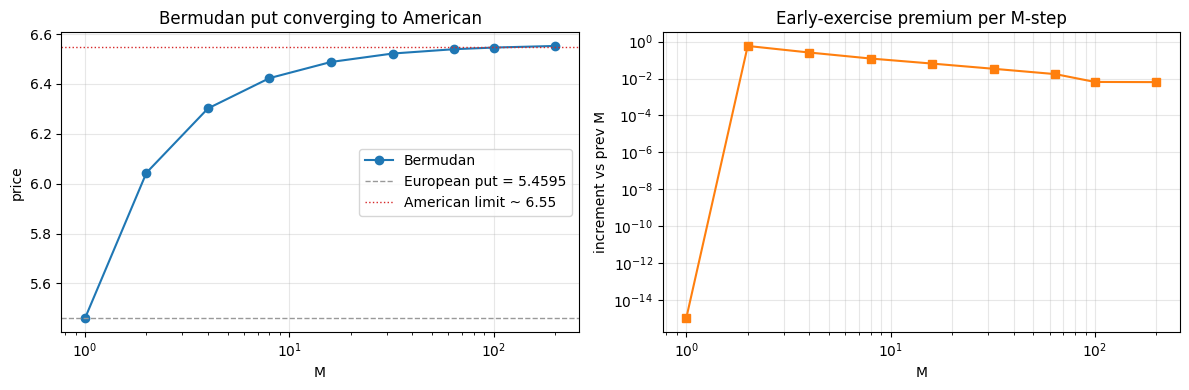

,M,Bermudan price,increment
0,1,5.45953,-2.66454e-15
1,2,6.04394,0.584408
2,4,6.3018,0.257863
3,8,6.42335,0.121546
4,16,6.48809,0.0647446
5,32,6.52188,0.0337897
6,64,6.53931,0.0174268
7,100,6.54587,0.00655758
8,200,6.55228,0.00641564


In [16]:
ber.n_cos = 128
prev = eu
rows = []
for M in [1, 2, 4, 8, 16, 32, 64, 100, 200]:
    ber.n_exercise = M
    p = ber.price_bermudan(K_b, S_b, T_b, cp=-1)
    rows.append((M, p, p - prev))
    prev = p
df_ber = pd.DataFrame(rows, columns=["M", "Bermudan price", "increment"])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(df_ber["M"], df_ber["Bermudan price"], "o-", color="#1f77b4", label="Bermudan")
a1.axhline(eu,   color="#999",    linestyle="--", linewidth=1.0, label=f"European put = {eu:.4f}")
a1.axhline(6.55, color="#d62728", linestyle=":",  linewidth=1.0, label="American limit ~ 6.55")
a1.set(xlabel="M", ylabel="price", title="Bermudan put converging to American")
a1.set_xscale("log"); a1.grid(True, alpha=0.3); a1.legend()
a2.semilogy(df_ber["M"], df_ber["increment"].clip(lower=1e-15), "s-", color="#ff7f0e")
a2.set(xlabel="M", ylabel="increment vs prev M", title="Early-exercise premium per M-step")
a2.set_xscale("log"); a2.grid(True, which="both", alpha=0.3)
fig.tight_layout(); plt.show()
df_ber

# 10. Post-presentation extension: strike-independent smiles and JP ranges

This section updates the project after the class presentation.  The point is to move from pricing one option at a time to pricing a whole volatility smile more like a production calibration routine.

## 10.1 Strike-independent COS setup

For fixed model parameters, expiry, forward, discount factor, and interval $[a,b]$, the expensive density side is strike-independent:

- cosine grid $u_k = k\pi/(b-a)$
- characteristic-function samples $\varphi(u_k)$
- phase-shifted, prime-weighted real density coefficients

The strike still enters through the payoff boundary $\log(K/F)$, so payoff coefficients are rebuilt for the strike vector.  But the density coefficients can be cached once and reused.

In code this is:

```python
setup = make_cos_smile_setup(cf, T, fwd, df, n_cos=N, trunc_range=(a, b))
prices = setup.price(strikes, cp=1)
```

The existing `price(...)` path remains unchanged.


In [17]:
from cos_pricing import CgmyModel, make_cos_smile_setup

model_smile = CgmyModel(C=1.0, G=5.0, M=10.0, Y=1.5, intr=0.1, divr=0.0)
S_smile, T_smile, N_smile = 100.0, 1.0, 512
fwd_smile, df_smile = model_smile._fwd_df(S_smile, T_smile)
cf_smile = model_smile.char_func(T_smile)
trunc_smile = model_smile.trunc_range(T_smile)
setup_smile = make_cos_smile_setup(
    cf_smile, T_smile, fwd_smile, df_smile,
    n_cos=N_smile, trunc_range=trunc_smile,
)

def _mean_ms(fn, repeats=120):
    fn()  # warm-up
    t0 = time.perf_counter()
    for _ in range(repeats):
        fn()
    return (time.perf_counter() - t0) / repeats * 1e3

rows = []
for n_strikes in [5, 25, 101]:
    strikes = np.linspace(60.0, 140.0, n_strikes)

    def scalar_loop():
        return np.array([
            model_smile.price(float(K), S_smile, T_smile, cp=1, n_cos=N_smile)
            for K in strikes
        ])

    def vector_price():
        return model_smile.price(strikes, S_smile, T_smile, cp=1, n_cos=N_smile)

    def setup_price():
        return setup_smile.price(strikes, cp=1)

    scalar_ms = _mean_ms(scalar_loop)
    vector_ms = _mean_ms(vector_price)
    setup_ms = _mean_ms(setup_price)
    ref = vector_price()
    rows.append({
        "strikes": n_strikes,
        "scalar loop ms": scalar_ms,
        "vector price ms": vector_ms,
        "reusable setup ms": setup_ms,
        "loop/setup speedup": scalar_ms / setup_ms,
        "vector/setup speedup": vector_ms / setup_ms,
        "max |setup-vector|": float(np.max(np.abs(setup_price() - ref))),
    })

df_smile_bench = pd.DataFrame(rows)
df_smile_bench


,strikes,scalar loop ms,vector price ms,reusable setup ms,loop/setup speedup,vector/setup speedup,max |setup-vector|
0,5,0.449499,0.116234,0.0531021,8.46481,2.18887,0
1,25,2.25876,0.223469,0.159645,14.1486,1.39979,0
2,101,11.0926,1.62795,1.31512,8.43464,1.23787,0


## 10.2 Junike-Pankrashkin range selection

Junike-Pankrashkin (2022) chooses the COS truncation range using Markov's inequality on the centered log-return.  In words:

1. Center the log-return around its mean.
2. Use an even central moment, typically the 8th moment, to bound tail probability.
3. Pick a symmetric half-width $L$ large enough for the requested tolerance.
4. Use the interval $[c_1-L, c_1+L]$ in the log-forward variable.

We implemented this as an optional range, not as the default.  The Fang-Oosterlee ranges remain unchanged unless we explicitly call `jp_trunc_range(...)` or `trunc_range="jp"`.


In [18]:
from cos_pricing import BsmModel, VgModel

range_models = [
    ("BSM", BsmModel(sigma=0.2), 1.0),
    ("VG", VgModel(sigma=0.12, theta=-0.14, nu=0.2, intr=0.1), 1.0),
    ("CGMY", CgmyModel(C=1.0, G=5.0, M=10.0, Y=0.5, intr=0.1), 1.0),
]
range_rows = []
for name, model, T in range_models:
    fo_a, fo_b = model.trunc_range(T)
    for eps in [1e-4, 1e-6, 1e-8]:
        jp_a, jp_b = model.jp_trunc_range(T, eps_tol=eps, moment_order=8)
        range_rows.append({
            "model": name,
            "eps": eps,
            "FO width": fo_b - fo_a,
            "JP width": jp_b - jp_a,
            "JP center": 0.5 * (jp_a + jp_b),
            "FO center": 0.5 * (fo_a + fo_b),
        })

df_jp_ranges = pd.DataFrame(range_rows)
df_jp_ranges


,model,eps,FO width,JP width,JP center,FO center
0,BSM,0.0001,4.8,3.6028,-0.02,-0.02
1,BSM,1e-06,4.8,4.97969,-0.02,-0.02
2,BSM,1e-08,4.8,7.80436,-0.02,-0.02
3,VG,0.0001,3.74183,2.4555,-0.00893297,-0.00893297
4,VG,1e-06,3.74183,3.63229,-0.00893297,-0.00893297
5,VG,1e-08,3.74183,6.45923,-0.00893297,-0.00893297
6,CGMY,0.0001,10,5.95319,-0.0508652,0
7,CGMY,1e-06,10,9.25423,-0.0508652,0
8,CGMY,1e-08,10,16.4566,-0.0508652,0


## 10.3 Black-Scholes control variate

The Black-Scholes control variate is implemented as an optional COS path:

$$
C_{model}^{CV}=C_{model}^{COS}+\left(C_{BS}^{exact}-C_{BS}^{COS}\right).
$$

Plain-English idea: price the difficult model with COS, then use Black-Scholes as a cheap "known answer" to estimate how much COS truncation error the same grid creates. We add that correction to the difficult model price.

The correction term measures the COS truncation/series error in a Black-Scholes model where the exact price is known. The key is that the Black-Scholes COS leg uses the same log-forward interval as the target model, so the correction is aimed at the same numerical range/grid error.

We compare three strike-independent BS volatility choices:

- **Simple:** Heston uses $\sqrt{E[\bar V_T]}$; VG/CGMY use $\sqrt{c_2/T}$.
- **Joshi-Yang real-axis:** Eq. (3.5), matching the first derivatives of the target and BS characteristic functions at $-i$. In MGF notation this is $\sigma^2 = 2K'(1)/T$ for $K(u)=\log E[e^{u\log(S_T/F)}]$.
- **Joshi-Yang half-contour:** Eq. (3.4) with $\eta=1/2$, matching characteristic-function values on the common Hermitian contour.

How to read the output:

- `plain |err|` is the error before the control variate.
- `simple CV |err|`, `JY real |err|`, and `JY half |err|` are errors after the correction.
- Smaller error is better.
- The `vol` columns show which equivalent Black-Scholes volatility was used for that correction.
- When all errors become the same at larger $N$, COS is already accurate and the control variate has little left to fix.

This remains opt-in: Joshi-Yang improves Heston and VG in these examples, while CGMY shows that no single equivalent-vol choice dominates every jump-model regime.



**Visible saved result.** The table below is written directly in markdown so it remains visible even if a notebook viewer hides or clears code-cell outputs. The code cell that follows recomputes the same numbers and prints a detailed table/chart.

**Takeaway summary.** The control variate is most useful when $N$ is small and the COS grid is still coarse.

| Model | Coarse N | Plain COS error | Best control-variate method | Best CV error | Improvement factor |
|---|---:|---:|---|---:|---:|
| Heston | 8 | 4.02248 | Joshi-Yang real-axis | 0.303819 | 13.24x |
| VG | 16 | 0.476249 | Joshi-Yang real-axis | 0.128903 | 3.69x |
| CGMY Y=0.5 | 16 | 8.95118 | Simple variance-matched CV | 2.34875 | 3.81x |

At larger $N$, the control-variate errors become the same as the plain COS errors because the Black-Scholes COS correction term is already nearly zero. In other words, the correction helps most at coarse resolution; once COS has converged, there is little left to fix.


10.3 Black-Scholes control variate results
Summary table: smaller errors are better; improvement factor = plain COS error / best CV error at coarse N.


,coarse N,plain |err|,best CV method,best CV |err|,improvement factor
model,,,,,
Heston,8,4.02248,Joshi-Yang real-axis,0.303819,13.2397
VG,16,0.476249,Joshi-Yang real-axis,0.128903,3.69464
CGMY Y=0.5,16,8.95118,Simple variance-matched CV,2.34875,3.81104


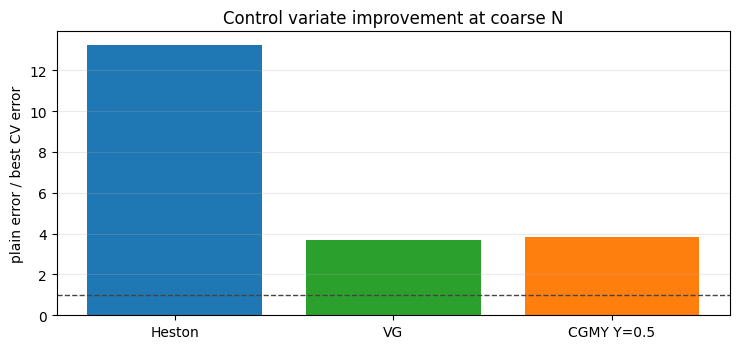

Detailed error table


plain |err|  simple CV |err|  JY real |err|  JY half |err|  \
model      N                                                                 
Heston     8        4.02248         0.388724       0.303819       0.342188   
           16       0.67061         0.423467       0.387502       0.404497   
           32     0.0536316        0.0532911      0.0529966      0.0531543   
           64   0.000578452      0.000578452    0.000578452    0.000578452   
VG         16      0.476249         0.156658       0.128903       0.135725   
           32    0.00304306        0.0026614     0.00252459       0.002561   
           64   1.12628e-05      1.12628e-05    1.12628e-05    1.12628e-05   
           128  6.85777e-09       6.8578e-09    6.85777e-09    6.85773e-09   
CGMY Y=0.5 16       8.95118          2.34875        2.92628        2.68767   
           32     0.0253781        0.0232846      0.0239695      0.0237102   
           64   0.000265881      0.000265881    0.000265881    0.000265881   
           128  3.16088e-08      3.16102e-08    3.16096e-08     3.1609e-08   

                simple vol  JY real vol  JY half vol  
model      N                                          
Heston     8      0.169056     0.161373     0.164943  
           16     0.169056     0.161373     0.164943  
           32     0.169056     0.161373     0.164943  
           64     0.169056     0.161373     0.164943  
VG         16     0.135351     0.132035     0.132832  
           32     0.135351     0.132035     0.132832  
           64     0.135351     0.132035     0.132832  
           128    0.135351     0.132035     0.132832  
CGMY Y=0.5 16     0.398162     0.405825     0.402596  
           32     0.398162     0.405825     0.402596  
           64     0.398162     0.405825     0.402596  
           128    0.398162     0.405825     0.402596

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from cos_pricing import HestonCOSPricer, VgModel, CgmyModel

# Keep this cell runnable by itself in VS Code/Jupyter.
PAPER_103 = globals().get("PAPER", dict(
    sigma=0.0175,
    vov=0.5751,
    mr=1.5768,
    theta=0.0398,
    rho=-0.5711,
    intr=0.0,
    divr=0.0,
))
REFS_103 = globals().get("REFS", {1.0: 5.785155435, 10.0: 22.318945791474590})

heston_cv = HestonCOSPricer(
    S0=100.0,
    v0=PAPER_103["sigma"],
    lam=PAPER_103["mr"],
    eta=PAPER_103["vov"],
    ubar=PAPER_103["theta"],
    rho=PAPER_103["rho"],
    r=PAPER_103["intr"],
    q=PAPER_103["divr"],
)
vg_cv = VgModel(sigma=0.12, theta=-0.14, nu=0.2, intr=0.1, divr=0.0)
cgmy_cv = CgmyModel(C=1.0, G=5.0, M=5.0, Y=0.5, intr=0.1, divr=0.0)

cv_specs = [
    ("Heston", [8, 16, 32, 64], REFS_103[1.0],
     lambda N: heston_cv.price_call(100.0, 1.0, N=N),
     lambda N, method: heston_cv.price_call_cv(100.0, 1.0, N=N, vol_method=method),
     lambda method: heston_cv.equivalent_bsm_vol(1.0, method=method)),
    ("VG", [16, 32, 64, 128], 19.099354724,
     lambda N: vg_cv.price(90.0, 100.0, 1.0, cp=1, n_cos=N),
     lambda N, method: vg_cv.price_cv(90.0, 100.0, 1.0, cp=1, n_cos=N, vol_method=method),
     lambda method: vg_cv.equivalent_bsm_vol(1.0, method=method)),
    ("CGMY Y=0.5", [16, 32, 64, 128], 19.8129488424,
     lambda N: cgmy_cv.price(100.0, 100.0, 1.0, cp=1, n_cos=N),
     lambda N, method: cgmy_cv.price_cv(100.0, 100.0, 1.0, cp=1, n_cos=N, vol_method=method),
     lambda method: cgmy_cv.equivalent_bsm_vol(1.0, method=method)),
]

cv_rows = []
for name, n_list, ref, plain_fn, cv_fn, vol_fn in cv_specs:
    vols = {method: vol_fn(method) for method in ["simple", "joshi", "joshi-half"]}
    for N in n_list:
        plain = plain_fn(N)
        cv_simple = cv_fn(N, "simple")
        cv_joshi = cv_fn(N, "joshi")
        cv_half = cv_fn(N, "joshi-half")
        cv_rows.append({
            "model": name,
            "N": N,
            "plain |err|": abs(plain - ref),
            "simple CV |err|": abs(cv_simple - ref),
            "JY real |err|": abs(cv_joshi - ref),
            "JY half |err|": abs(cv_half - ref),
            "simple vol": vols["simple"],
            "JY real vol": vols["joshi"],
            "JY half vol": vols["joshi-half"],
        })

df_cv = pd.DataFrame(cv_rows).set_index(["model", "N"])
summary_rows = []
method_cols = ["simple CV |err|", "JY real |err|", "JY half |err|"]
method_names = {
    "simple CV |err|": "Simple variance-matched CV",
    "JY real |err|": "Joshi-Yang real-axis",
    "JY half |err|": "Joshi-Yang half-contour",
}
for name, n_list, *_ in cv_specs:
    first_N = n_list[0]
    first_row = df_cv.loc[(name, first_N)]
    best_col = min(method_cols, key=lambda col: first_row[col])
    summary_rows.append({
        "model": name,
        "coarse N": first_N,
        "plain |err|": first_row["plain |err|"],
        "best CV method": method_names[best_col],
        "best CV |err|": first_row[best_col],
        "improvement factor": first_row["plain |err|"] / first_row[best_col],
    })

df_cv_summary = pd.DataFrame(summary_rows).set_index("model")

print("10.3 Black-Scholes control variate results")
print("Summary table: smaller errors are better; improvement factor = plain COS error / best CV error at coarse N.")
display(df_cv_summary)

fig, ax = plt.subplots(figsize=(7.5, 3.6))
colors = ["#1f77b4", "#2ca02c", "#ff7f0e"]
for color, (name, *_rest) in zip(colors, cv_specs):
    row = df_cv_summary.loc[name]
    ax.bar(name, row["improvement factor"], color=color)
ax.axhline(1.0, color="#444", linewidth=1.0, linestyle="--")
ax.set_ylabel("plain error / best CV error")
ax.set_title("Control variate improvement at coarse N")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout(); plt.show()

print("Detailed error table")
display(df_cv)


# 11. Final validation checklist

This last section is the quality-control summary for the project. It is intentionally short: the detailed validations are above, and the automated tests live in `tests/`.


In [20]:
validation_rows = [
    ("Notebook execution", "passes end-to-end", "this cell ran after all previous sections"),
    ("Automated tests", "232 passed, 4 skipped", "includes fixed-seed randomized BSM/Heston/VG/CGMY robustness"),
    ("Default pricing path", "unchanged", "`price(...)` remains the baseline Fang-Oosterlee COS path"),
    ("New extensions", "opt-in", "strike-independent setup, JP ranges, and BS control variates require explicit calls"),
    ("Known caveat", "documented", "CGMY Y=1.98 is treated as a numerical-convention/reference mismatch"),
]
pd.DataFrame(validation_rows, columns=["check", "status", "evidence"])


,check,status,evidence
0,Notebook execution,passes end-to-end,this cell ran after all previous sections
1,Automated tests,"232 passed, 4 skipped",includes fixed-seed randomized BSM/Heston/VG/C...
2,Default pricing path,unchanged,`price(...)` remains the baseline Fang-Oosterl...
3,New extensions,opt-in,"strike-independent setup, JP ranges, and BS co..."
4,Known caveat,documented,CGMY Y=1.98 is treated as a numerical-conventi...
